In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Load dataset
df = pd.read_csv('data/df_features_with_label_standardised.csv')

In [2]:
# 2. Separate features (X) from identifiers and target labels (y)
columns_to_exclude = ['date', 'symbol', 'value_classification', 'gsadf_label_95', 'gsadf_label_90']
# This safely drops the columns only if they exist in the new dataset
X = df.drop(columns=[col for col in columns_to_exclude if col in df.columns])

In [3]:
# 3. Handle any sneaky missing or infinite values just in case
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X = X.ffill().bfill().fillna(0)

In [4]:
# 4. Fit PCA directly 
pca = PCA()
pca.fit(X)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


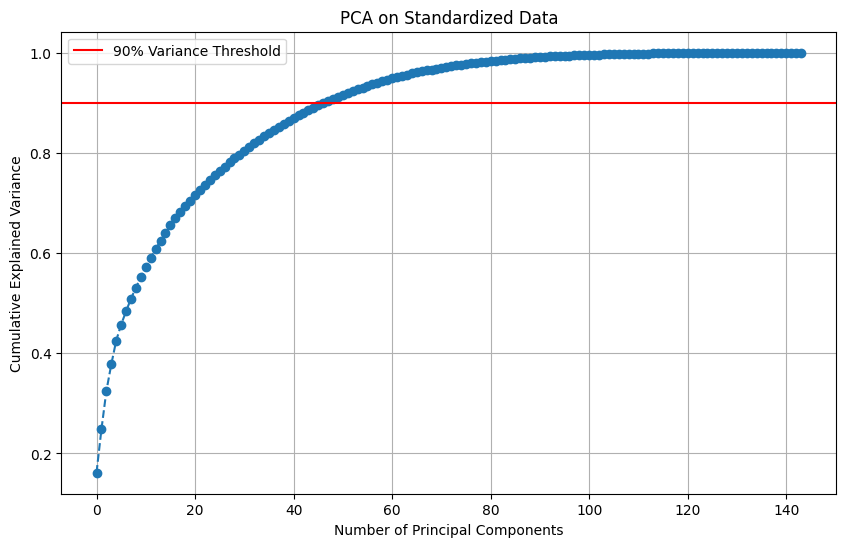

In [5]:
# Plot the variance graph to double check the components
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.axhline(y=0.90, color='r', linestyle='-', label='90% Variance Threshold')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA on Standardized Data')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
# 5. Apply Final PCA for 90% variance
pca_final = PCA(n_components=0.90)
X_pca = pca_final.fit_transform(X)

print(f"Original number of features: {X.shape[1]}")
print(f"Number of PCA components kept: {X_pca.shape[1]}")

Original number of features: 144
Number of PCA components kept: 48


In [7]:
# 6. Reconstruct a new DataFrame with PCA components
pca_columns = [f'PC{i+1}' for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(X_pca, columns=pca_columns)

In [8]:
# 7. Add important columns back safely
if 'date' in df.columns: df_pca.insert(0, 'date', df['date'])
if 'symbol' in df.columns: df_pca.insert(1, 'symbol', df['symbol'])
if 'gsadf_label_95' in df.columns: df_pca['gsadf_label_95'] = df['gsadf_label_95']
if 'gsadf_label_90' in df.columns: df_pca['gsadf_label_90'] = df['gsadf_label_90']

In [9]:
# 8. Save the output 
df_pca.to_csv('data/outputs/pca_features_standardised.csv', index=False)
print("Success! 'pca_features_standardised.csv' has been saved.")

Success! 'pca_features_standardised.csv' has been saved.
